In [2]:
from Levenshtein import editops # To track actions for transpositions
from nltk import edit_distance # For Damerau–Levenshtein distance

import os

from denovo_utils.data import Run
from denovo_utils.parsers import DenovoEngineConverter
from denovo_utils.io.read import load_psmlist

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

from denovo_utils.analysis.metrics import load_seq_score_dicts
from denovo_utils.analysis.metrics import get_match_score_table, get_prc_curve

from psm_utils import Peptidoform
from tqdm import tqdm
from peak_pack.utils import calculate_ppm

from denovo_utils.analysis.metrics import (
    get_refinement_error_tables,
    plot_refinement_error_table,
    plot_precision_recall_refinement
)

import pandas as pd

from denovo_utils.analysis.error_types import SequenceComparison

from tqdm import tqdm

2026-09-09 15:47:01.729367: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modification already exists in ModificationsDB. Skipping.


In [3]:
engine_order = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'NovoB',
    'InstaNovo',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]
engine_order_renamed = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'NovoB',
    'InstaNovo',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

denovo_engines = denovo_names = [
    'AdaNovo',
    'Casanovo4.2.0',
    'ContraNovo',
    'NovoB',
    'InstaNovo',
    'PepNet',
    'pi-HelixNovo',
    'pi-PrimeNovo',
]

In [4]:
import pickle
with open('runs_PXD028735_QExactive_modcleanup_refinement.pkl', 'rb') as f:
    runs = pickle.load(f)

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7ffa0f9af510>>
Traceback (most recent call last):
  File "/home/sam/miniconda3/envs/denovo_analysis_env/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


In [5]:
from figsave import autosave
autosave("figures", formats=("svg", "pdf"))

PosixPath('figures')

In [43]:
import numpy as np


def get_seq_comparison(psm_1, psm_2, non_symmetry_list=None, spectrum=None):
    try:
        # Ignores I and L
        sc = SequenceComparison(
            identifier=None,
            peptide_source=psm_1.peptidoform,
            peptide_target=psm_2.peptidoform
        )
        sc.add_evidence(
            evidence_source=psm_1.peptide_evidence,
            evidence_target=psm_2.peptide_evidence
        )
        sc.calculate_distance()
        sc.annotate_tags(with_evidence=True)
        if not sc.symmetric and non_symmetry_list is not None and spectrum is not None:
            non_symmetry_list.append(spectrum.spectrum_id)
        return sc
    except:
        raise Exception('Error for {}'.format(spectrum))
    
def construct_entry(
        comparison_type,
        psm_gt,
        psm_candidate,
        psm_refined=None,
        refinement_type=None,
        non_symmetry_list=None,
        spectrum=None
    ):

    # Get score differences
    ms2rescore_diff_gt_candidate = psm_gt.scores.get_score('score_ms2rescore') - psm_candidate.scores.get_score('score_ms2rescore')
    if psm_refined is not None:
        ms2rescore_diff_candidate_refinement = psm_candidate.scores.get_score('score_ms2rescore') - psm_refined.scores.get_score('score_ms2rescore')
        ms2rescore_diff_gt_refinement = psm_gt.scores.get_score('score_ms2rescore') - psm_refined.scores.get_score('score_ms2rescore')
    else:
        ms2rescore_diff_candidate_refinement = np.nan
        ms2rescore_diff_gt_refinement = np.nan

    # base
    entry = {
        'type': comparison_type,
        'engine': psm_candidate.engine_name,
        'refiner': refinement_type,
        'ms2rescore_diff_gt_candidate': ms2rescore_diff_gt_candidate,
        'ms2rescore_diff_candidate_refinement': ms2rescore_diff_candidate_refinement,
        'ms2rescore_diff_gt_refinement': ms2rescore_diff_gt_refinement
    }

    # Scenario 2: correct yet refined
    if comparison_type == 'correct-perturbed':
        sc = get_seq_comparison(
            psm_1=psm_gt,
            psm_2=psm_refined,
            non_symmetry_list=non_symmetry_list,
            spectrum=spectrum
        )
        entry['sc_gt_refinement'] = sc
        entry['sc_gt_candidate'] = None
        entry['sc_candidate_refinement'] = None
        
    
    elif comparison_type in ['wrong-unperturbed', 'corrected-by-refinement']:
        sc = get_seq_comparison(
            psm_1=psm_gt,
            psm_2=psm_candidate,
            non_symmetry_list=non_symmetry_list,
            spectrum=spectrum
        )
        entry['sc_gt_refinement'] = None
        entry['sc_gt_candidate'] = sc
        entry['sc_candidate_refinement'] = None

    elif comparison_type == 'wrong-wrong':
        sc_1 = get_seq_comparison(
            psm_1=psm_gt,
            psm_2=psm_refined,
            non_symmetry_list=non_symmetry_list,
            spectrum=spectrum
        )
        sc_2 = get_seq_comparison(
            psm_1=psm_gt,
            psm_2=psm_candidate,
            non_symmetry_list=non_symmetry_list,
            spectrum=spectrum
        )
        sc_3 = get_seq_comparison(
            psm_1=psm_candidate,
            psm_2=psm_refined,
            non_symmetry_list=non_symmetry_list,
            spectrum=spectrum
        )
        entry['sc_gt_refinement'] = sc_1
        entry['sc_gt_candidate'] = sc_2
        entry['sc_candidate_refinement'] = sc_3
    return entry

In [39]:
# when focussing on refinement, we should leave out some spectra
from copy import deepcopy

modifications = {
    'UNIMOD:35': [],
    'UNIMOD:1': [],
    'UNIMOD:385': [],
    'Q[UNIMOD:7]': [],
    'N[UNIMOD:7]': [],
    'UNIMOD:5': [],
    'Formula:H-2C1O1': [],
    'S[UNIMOD:21]': [],
    'T[UNIMOD:21]': [],
    'Y[UNIMOD:21]': [],
}

modifications_per_run = {
    k: deepcopy(modifications) for k in runs.keys()
}

for run_name, run in runs.items():
    for spectrum_id, spectrum in run.spectra.items():
        modifications_ = modifications_per_run[run_name]

        # Collect all proforma strings for this spectrum
        candidates = [
            candidate.peptidoform.proforma
            for candidate in spectrum.psm_gold_standard
        ]

        # Skip spectra without candidates (just in case)
        if not candidates:
            continue

        for modification in modifications_.keys():
            # Check if modification is present in ALL candidates
            if all(modification in peptide for peptide in candidates):
                modifications_[modification].append(spectrum_id)

In [42]:
from copy import deepcopy

def mod_in_psm(psm, modifications):
    proforma = psm.peptidoform.proforma
    for modification in modifications:
        if modification in proforma:
            return True
    return False

def filter_on_mods(run, modifications, filter_candidates=True, filter_gold_standard=True):
    removed = {}
    new_run = Run(run_id=run.run_id)
    for spectrum_id, spectrum in tqdm(run.spectra.items()):
        if filter_gold_standard:
            
            if all(
                [
                    mod_in_psm(psm_gold_standard, modifications) for psm_gold_standard
                    in spectrum.psm_gold_standard
                ]):
                continue
    
        if filter_candidates:
            new_candidate_list = []
            for candidate in spectrum.psm_candidates:
                if mod_in_psm(candidate, modifications):
                    if candidate.engine_name in removed.keys():
                        removed[candidate.engine_name] += 1
                    else:
                        removed[candidate.engine_name] = 1
                    continue
                new_candidate_list.append(candidate)
            spectrum = deepcopy(spectrum)
            spectrum.psm_candidates = new_candidate_list
        new_run.spectra[spectrum_id] = spectrum
    return new_run, removed

unsupported_by_spectralis = [
    'UNIMOD:1',
    'UNIMOD:385',
    'UNIMOD:5',
    'Formula:H-2C1O1',
    'S[UNIMOD:21]',
    'T[UNIMOD:21]',
    'Y[UNIMOD:21]',
    'Q[UNIMOD:7]',
    'N[UNIMOD:7]'
]
unsupported_by_instanovoplus = [
    '[+25.980265]-',
    '[Formula:H-2C1O1]',
    'S[UNIMOD:21]',
    'T[UNIMOD:21]',
    'Y[UNIMOD:21]',
]

runs_spectralis = {}
runs_instanovo = {}

for run_name, run in runs.items():
    runs_spectralis[run_name], _ = filter_on_mods(
        run=run,
        modifications=unsupported_by_spectralis,
        filter_candidates=True,
        filter_gold_standard=True
    )
    print(run_name, 'Spectralis', _)

for run_name, run in runs.items():
    runs_instanovo[run_name], _ = filter_on_mods(
        run=run,
        modifications=unsupported_by_instanovoplus,
        filter_candidates=True,
        filter_gold_standard=True
    )
    print(run_name, 'IN+', _)

100%|██████████| 19820/19820 [00:24<00:00, 824.45it/s] 


LFQ_Orbitrap_DDA_Ecoli_01 Spectralis {'InstaNovo': 447, 'AdaNovo': 334, 'pi-HelixNovo': 2917, 'ContraNovo': 1037, 'pi-PrimeNovo': 852, 'Casanovo4.2.0': 1110}


100%|██████████| 72028/72028 [04:44<00:00, 253.55it/s] 


LFQ_Orbitrap_DDA_Human_01 Spectralis {'ContraNovo': 4391, 'pi-HelixNovo': 12515, 'AdaNovo': 1569, 'pi-PrimeNovo': 3598, 'Casanovo4.2.0': 4054, 'InstaNovo': 1179}


100%|██████████| 67043/67043 [01:31<00:00, 732.93it/s] 


...

LFQ_Orbitrap_DDA_Human_01 IN+ {'InstaNovo': 90, 'ContraNovo': 44, 'pi-HelixNovo': 39, 'pi-PrimeNovo': 40, 'Casanovo4.2.0': 3}


100%|██████████| 67043/67043 [01:33<00:00, 718.61it/s] 


LFQ_Orbitrap_DDA_QC_01 IN+ {'ContraNovo': 40, 'InstaNovo': 72, 'pi-PrimeNovo': 39, 'pi-HelixNovo': 36, 'Casanovo4.2.0': 4}


100%|██████████| 49588/49588 [01:06<00:00, 746.80it/s] 

LFQ_Orbitrap_DDA_Yeast_01 IN+ {'InstaNovo': 72, 'pi-PrimeNovo': 46, 'ContraNovo': 21, 'pi-HelixNovo': 32, 'Casanovo4.2.0': 4}


In [ ]:
# non_symmetries = {}
# levenshtein_df = []

# def get_best_gold_standard(candidate, psm_gold_standard):
#     best_rank = None
#     for rank, evaluation in candidate.evaluations.items():
#         if evaluation['score_ms2rescore'].error_type == 'match':
#             best_rank = rank
#             break
    
#     for gs in psm_gold_standard:
#         if best_rank is None:
#             if gs.rank == 1:
#                 return gs
#         elif gs.rank == best_rank:
#             return gs

# for run in runs.values():
#     non_symmetries[run.run_id] = []

#     for spectrum in tqdm(run.spectra.values()):
#         psm_gold_standard = spectrum.psm_gold_standard

#         for psm_candidate in spectrum.psm_candidates:
#             # Get the correct reference (only for matches, otherwise take rank 1)
#             psm_gt = get_best_gold_standard(psm_candidate, psm_gold_standard)
#             type_ = 'ignore'
#             try:
#                 spectralis = psm_candidate.refinement['Spectralis']
#             except:
#                 spectralis = False
#             try:
#                 instanovoplus = psm_candidate.refinement['InstaNovo+']
#             except:
#                 instanovoplus = False
        
#             # FIRST FOR SPECTRALIS
#             for refinement, refiner_name in zip([spectralis, instanovoplus], ['Spectralis', "InstaNovo+"]):
#                 if refinement:
#                     # Scenario 2: If the original was correct
#                     unrefined = refinement[1]
#                     psm_refined = refinement[0]

#                     # Correct the evaluation (did not ignore IvsL)
#                     # if not unrefined:
#                     #     unrefined = psm_refined.peptidoform.proforma.replace('L', 'I') == psm_candidate.peptidoform.proforma.replace('L', 'I')

#                     if psm_candidate.metadata['match_type'] == 'match':
#                         # Yet got perturbed anyhow
#                         if not unrefined: # refinement_made[1] == True if unperturbed
#                             entry = construct_entry(
#                                 comparison_type='correct-perturbed',
#                                 psm_gt=psm_gt,
#                                 psm_candidate=psm_candidate,
#                                 psm_refined=psm_refined,
#                                 refinement_type=refiner_name,
#                                 non_symmetry_list=non_symmetries[run.run_id],
#                                 spectrum=spectrum
#                             )
#                         else: # Correct and left as correct
#                             continue

#                     # If the original was incorrect
#                     if psm_candidate.metadata['match_type'] != 'match':
#                         # And remained unchanged
#                         # SCENARIO 1
#                         if unrefined:
#                             entry = construct_entry(
#                                 comparison_type='wrong-unperturbed',
#                                 psm_gt=psm_gt,
#                                 psm_candidate=psm_candidate,
#                                 psm_refined=psm_refined,
#                                 refinement_type=refiner_name,
#                                 non_symmetry_list=non_symmetries[run.run_id],
#                                 spectrum=spectrum
#                             )
                            

#                         # And got corrected
#                         elif psm_refined.metadata['match_type'] == 'match':
#                             entry = construct_entry(
#                                 comparison_type='corrected-by-refinement',
#                                 psm_gt=psm_gt,
#                                 psm_candidate=psm_candidate,
#                                 psm_refined=psm_refined,
#                                 refinement_type=refiner_name,
#                                 non_symmetry_list=non_symmetries[run.run_id],
#                                 spectrum=spectrum
#                             )
                            
                        
#                         # And remained incorrect
#                         else:
#                             entry = construct_entry(
#                                 comparison_type='wrong-wrong',
#                                 psm_gt=psm_gt,
#                                 psm_candidate=psm_candidate,
#                                 psm_refined=psm_refined,
#                                 refinement_type=refiner_name,
#                                 non_symmetry_list=non_symmetries[run.run_id],
#                                 spectrum=spectrum
#                             )
                            
#                     levenshtein_df.append(entry)
#                 else:
#                     continue

# levenshtein_df = pd.DataFrame(levenshtein_df)

In [47]:
non_symmetries = {}
levenshtein_df = []

def get_best_gold_standard(candidate, psm_gold_standard):
    best_rank = None
    for rank, evaluation in candidate.evaluations.items():
        if evaluation['score_ms2rescore'].error_type == 'match':
            best_rank = rank
            break
    
    for gs in psm_gold_standard:
        if best_rank is None:
            if gs.rank == 1:
                return gs
        elif gs.rank == best_rank:
            return gs

for run in runs_instanovo.values():
    non_symmetries[run.run_id] = []

    for spectrum in tqdm(run.spectra.values()):
        psm_gold_standard = spectrum.psm_gold_standard

        for psm_candidate in spectrum.psm_candidates:
            # Get the correct reference (only for matches, otherwise take rank 1)
            psm_gt = get_best_gold_standard(psm_candidate, psm_gold_standard)
            type_ = 'ignore'
            # try:
            #     spectralis = psm_candidate.refinement['Spectralis']
            # except:
            #     spectralis = False
            try:
                instanovoplus = psm_candidate.refinement['InstaNovo+']
            except:
                instanovoplus = False
        
            # FIRST FOR SPECTRALIS
            for refinement, refiner_name in zip([instanovoplus], ["InstaNovo+"]):
                if refinement:
                    # Scenario 2: If the original was correct
                    unrefined = refinement[1]
                    psm_refined = refinement[0]

                    # Correct the evaluation (did not ignore IvsL)
                    if not unrefined:
                        unrefined = psm_refined.peptidoform.proforma.replace('L', 'I') == psm_candidate.peptidoform.proforma.replace('L', 'I')

                    if psm_candidate.metadata['match_type'] == 'match':
                        # Yet got perturbed anyhow
                        if not unrefined: # refinement_made[1] == True if unperturbed
                            entry = construct_entry(
                                comparison_type='correct-perturbed',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                        else: # Correct and left as correct
                            continue

                    # If the original was incorrect
                    if psm_candidate.metadata['match_type'] != 'match':
                        # And remained unchanged
                        # SCENARIO 1
                        if unrefined:
                            entry = construct_entry(
                                comparison_type='wrong-unperturbed',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            

                        # And got corrected
                        elif psm_refined.metadata['match_type'] == 'match':
                            entry = construct_entry(
                                comparison_type='corrected-by-refinement',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            
                        
                        # And remained incorrect
                        else:
                            entry = construct_entry(
                                comparison_type='wrong-wrong',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            
                    levenshtein_df.append(entry)
                else:
                    continue

levenshtein_df_instanovo = pd.DataFrame(levenshtein_df)

  0%|          | 0/19749 [00:00<?, ?it/s]

100%|██████████| 49298/49298 [02:14<00:00, 367.74it/s]


In [48]:
non_symmetries = {}
levenshtein_df = []

def get_best_gold_standard(candidate, psm_gold_standard):
    best_rank = None
    for rank, evaluation in candidate.evaluations.items():
        if evaluation['score_ms2rescore'].error_type == 'match':
            best_rank = rank
            break
    
    for gs in psm_gold_standard:
        if best_rank is None:
            if gs.rank == 1:
                return gs
        elif gs.rank == best_rank:
            return gs

for run in runs_spectralis.values():
    non_symmetries[run.run_id] = []

    for spectrum in tqdm(run.spectra.values()):
        psm_gold_standard = spectrum.psm_gold_standard

        for psm_candidate in spectrum.psm_candidates:
            # Get the correct reference (only for matches, otherwise take rank 1)
            psm_gt = get_best_gold_standard(psm_candidate, psm_gold_standard)
            type_ = 'ignore'
            try:
                spectralis = psm_candidate.refinement['Spectralis']
            except:
                spectralis = False
            # try:
            #     instanovoplus = psm_candidate.refinement['InstaNovo+']
            # except:
            #     instanovoplus = False
        
            # FIRST FOR SPECTRALIS
            for refinement, refiner_name in zip([spectralis], ["Spectralis"]):
                if refinement:
                    # Scenario 2: If the original was correct
                    unrefined = refinement[1]
                    psm_refined = refinement[0]

                    # Correct the evaluation (did not ignore IvsL)
                    if not unrefined:
                        unrefined = psm_refined.peptidoform.proforma.replace('L', 'I') == psm_candidate.peptidoform.proforma.replace('L', 'I')

                    if psm_candidate.metadata['match_type'] == 'match':
                        # Yet got perturbed anyhow
                        if not unrefined: # refinement_made[1] == True if unperturbed
                            entry = construct_entry(
                                comparison_type='correct-perturbed',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                        else: # Correct and left as correct
                            continue

                    # If the original was incorrect
                    if psm_candidate.metadata['match_type'] != 'match':
                        # And remained unchanged
                        # SCENARIO 1
                        if unrefined:
                            entry = construct_entry(
                                comparison_type='wrong-unperturbed',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            

                        # And got corrected
                        elif psm_refined.metadata['match_type'] == 'match':
                            entry = construct_entry(
                                comparison_type='corrected-by-refinement',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            
                        
                        # And remained incorrect
                        else:
                            entry = construct_entry(
                                comparison_type='wrong-wrong',
                                psm_gt=psm_gt,
                                psm_candidate=psm_candidate,
                                psm_refined=psm_refined,
                                refinement_type=refiner_name,
                                non_symmetry_list=non_symmetries[run.run_id],
                                spectrum=spectrum
                            )
                            
                    levenshtein_df.append(entry)
                else:
                    continue

levenshtein_df_spectralis = pd.DataFrame(levenshtein_df)

100%|██████████| 45034/45034 [02:19<00:00, 323.44it/s]


In [7]:
# Load results
with open('levenshtein_table_2_27_26.pkl', 'rb') as f:
    levenshtein_df = pickle.load(f)

In [33]:
class Selector:
    @staticmethod
    def get_spectra_from_model(run, denovo_models, include_gold_standard=False):
        spectra = {}
        for spectrum_id, spectrum in run.spectra.items():
            psms = []
            common = True
            for denovo_name in denovo_models:
                psm = spectrum.get_psms_by_engine(engine_name=denovo_name)
                if len(psm) == 0:
                    common = False
                    break
                psms += psm
            if common:
                if include_gold_standard:
                    psms += spectrum.psm_gold_standard
                spectra[spectrum_id] = spectrum
        
        new_run = Run(run.run_id)
        new_run.spectra = spectra
        return new_run

In [ ]:
# Count correct de novo predictions

n_correct = {
    engine: 0 for engine in denovo_engines
}

for run in runs.values():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for spectrum in tqdm(run_engine.spectra.values()):
            candidates = spectrum.get_psms_by_engine(engine)
            assert len(candidates)==1
            if candidates[0].metadata['match_type']=='match':
                n_correct[engine] += 1

n_predictions = {}

for engine in denovo_engines:
    n_predictions[engine] = sum([len(Selector.get_spectra_from_model(run, denovo_models=[engine])) for run in runs.values()])

100%|██████████| 47572/47572 [00:00<00:00, 247506.94it/s]


In [31]:
n_correct

{'AdaNovo': 73101,
 'Casanovo4.2.0': 89528,
 'ContraNovo': 52455,
 'NovoB': 89313,
 'InstaNovo': 92971,
 'PepNet': 49767,
 'pi-HelixNovo': 76679,
 'pi-PrimeNovo': 105164}

In [32]:
n_predictions

{'AdaNovo': 203842,
 'Casanovo4.2.0': 207135,
 'ContraNovo': 103957,
 'NovoB': 203183,
 'InstaNovo': 208002,
 'PepNet': 175004,
 'pi-HelixNovo': 207098,
 'pi-PrimeNovo': 201775}

In [ ]:
counts_df = levenshtein_df.groupby(['engine', 'refiner'])['type'].value_counts()
counts_df.name = 'counts'
counts_df = counts_df.reset_index()

counts_df['%'] = counts_df.apply(lambda x: x['counts']/n_predictions[x['engine']], axis=1)
counts_df['type'].unique()

array(['wrong-unperturbed', 'wrong-wrong', 'corrected-by-refinement',
       'correct-perturbed'], dtype=object)

In [ ]:
counts_df.groupby(['engine', 'refiner']).apply(
    lambda x: sum([c for c, t in zip(x['%'], x['type']) if t in [
        'wrong-wrong', 'correct-perturbed', 'corrected-by-refinement'
    ]])
)

In [35]:
counts_df.groupby(['engine', 'refiner']).apply(
    lambda x: sum([c for c, t in zip(x['%'], x['type']) if t in [
        'wrong-wrong', 'correct-perturbed', 'corrected-by-refinement'
    ]])
)

engine         refiner   
AdaNovo        InstaNovo+    0.119735
               Spectralis    0.313395
Casanovo4.2.0  InstaNovo+    0.082183
               Spectralis    0.350303
ContraNovo     InstaNovo+    0.109536
               Spectralis    0.409092
InstaNovo      InstaNovo+    0.141532
               Spectralis    0.310978
NovoB          InstaNovo+    0.103675
               Spectralis    0.334624
PepNet         InstaNovo+    0.352735
               Spectralis    0.332730
pi-HelixNovo   InstaNovo+    0.120706
               Spectralis    0.462491
pi-PrimeNovo   InstaNovo+    0.145330
               Spectralis    0.351416
dtype: float64

---

In [54]:
# New Spectralis runs:
# Count correct de novo predictions

# 1. calculate denominators
n_correct = {
    engine: 0 for engine in denovo_engines
}

for run in runs_spectralis.values():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for spectrum in tqdm(run_engine.spectra.values()):
            candidates = spectrum.get_psms_by_engine(engine)
            assert len(candidates)==1
            if candidates[0].metadata['match_type']=='match':
                n_correct[engine] += 1

n_predictions = {}


for engine in denovo_engines:
    n_predictions[engine] = sum([len(Selector.get_spectra_from_model(run, denovo_models=[engine])) for run in runs_spectralis.values()])

# 2. Calculate proportions    
counts_df_spectralis = levenshtein_df_spectralis.groupby(['engine', 'refiner'])['type'].value_counts()
counts_df_spectralis.name = 'counts'
counts_df_spectralis = counts_df_spectralis.reset_index()

counts_df_spectralis['%'] = counts_df_spectralis.apply(lambda x: x['counts']/n_predictions[x['engine']], axis=1)
counts_df_spectralis['type'].unique()

# 3. Show proportions
counts_df_spectralis.groupby(['engine', 'refiner']).apply(
    lambda x: sum([c for c, t in zip(x['%'], x['type']) if t in [
        'wrong-wrong', 'correct-perturbed', 'corrected-by-refinement'
    ]])
)

100%|██████████| 41533/41533 [00:00<00:00, 240033.33it/s]


engine         refiner   
AdaNovo        Spectralis    0.288192
Casanovo4.2.0  Spectralis    0.278558
ContraNovo     Spectralis    0.286607
InstaNovo      Spectralis    0.275959
NovoB          Spectralis    0.329389
PepNet         Spectralis    0.332640
pi-HelixNovo   Spectralis    0.308915
pi-PrimeNovo   Spectralis    0.295360
dtype: float64

In [55]:
# New instanovo runs:
# Count correct de novo predictions

# 1. calculate denominators
n_correct = {
    engine: 0 for engine in denovo_engines
}

for run in runs_instanovo.values():
    for engine in denovo_engines:
        run_engine = Selector.get_spectra_from_model(run, denovo_models=[engine])
        for spectrum in tqdm(run_engine.spectra.values()):
            candidates = spectrum.get_psms_by_engine(engine)
            assert len(candidates)==1
            if candidates[0].metadata['match_type']=='match':
                n_correct[engine] += 1

n_predictions = {}


for engine in denovo_engines:
    n_predictions[engine] = sum([len(Selector.get_spectra_from_model(run, denovo_models=[engine])) for run in runs_instanovo.values()])

# 2. Calculate proportions    
counts_df_instanovo = levenshtein_df_instanovo.groupby(['engine', 'refiner'])['type'].value_counts()
counts_df_instanovo.name = 'counts'
counts_df_instanovo = counts_df_instanovo.reset_index()

counts_df_instanovo['%'] = counts_df_instanovo.apply(lambda x: x['counts']/n_predictions[x['engine']], axis=1)
counts_df_instanovo['type'].unique()

# 3. Show proportions
counts_df_instanovo.groupby(['engine', 'refiner']).apply(
    lambda x: sum([c for c, t in zip(x['%'], x['type']) if t in [
        'wrong-wrong', 'correct-perturbed', 'corrected-by-refinement'
    ]])
)

100%|██████████| 47448/47448 [00:00<00:00, 239023.37it/s]


engine         refiner   
AdaNovo        InstaNovo+    0.119553
Casanovo4.2.0  InstaNovo+    0.081881
ContraNovo     InstaNovo+    0.109404
InstaNovo      InstaNovo+    0.140869
NovoB          InstaNovo+    0.102841
PepNet         InstaNovo+    0.352526
pi-HelixNovo   InstaNovo+    0.120553
pi-PrimeNovo   InstaNovo+    0.145072
dtype: float64

---

In [110]:
counts_df = pd.concat([counts_df_spectralis, counts_df_instanovo], ignore_index=True)
levenshtein_df = pd.concat([levenshtein_df_instanovo, levenshtein_df_spectralis], ignore_index=True)

# Show refinement types

In [111]:
counts_df['%'] = counts_df['%']*100

In [112]:
counts_df['% of correct'] = counts_df.apply(lambda x: x['counts']/n_correct[x['engine']], axis=1)
counts_df['% of incorrect'] = counts_df.apply(lambda x: x['counts']/(n_predictions[x['engine']] - n_correct[x['engine']]), axis=1)

In [113]:
counts_df.columns

Index(['engine', 'refiner', 'type', 'counts', '%', '% of correct',
       '% of incorrect'],
      dtype='object')

In [114]:
counts_df.groupby(['refiner', 'type'])[['counts', '%', '% of correct', '% of incorrect']].mean().reset_index()

,refiner,type,counts,%,% of correct,% of incorrect
0,InstaNovo+,correct-perturbed,707.625,0.393881,0.008840,0.007344
1,InstaNovo+,corrected-by-refinement,1671.375,0.906672,0.025663,0.014952
2,InstaNovo+,wrong-unperturbed,83066.250,43.660560,1.079180,0.759818
3,InstaNovo+,wrong-wrong,24906.750,13.358171,0.356318,0.225214
4,Spectralis,correct-perturbed,7224.875,4.478668,0.088252,0.072411
5,Spectralis,corrected-by-refinement,1928.375,1.149381,0.025582,0.017682
6,Spectralis,wrong-unperturbed,47955.000,28.099625,0.645989,0.428182
7,Spectralis,wrong-wrong,40930.000,24.317194,0.547985,0.371747


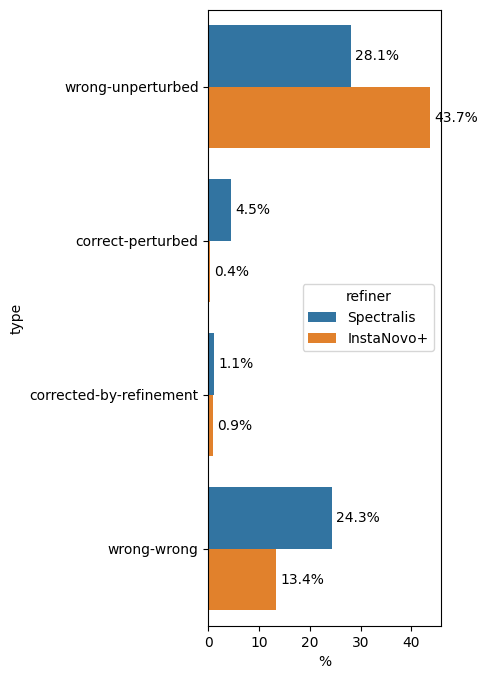

In [ ]:
# Your plot
plt.figure(figsize=(3,8))
ax = sns.barplot(
    data=counts_df.groupby(['refiner', 'type'])[['counts', '%']].mean().reset_index(),
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+'],
    order=['wrong-unperturbed', 'correct-perturbed', 'corrected-by-refinement', 'wrong-wrong'],
    y='type',
    x='%'
)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.show("F2B_PSMsperScenario")

In [116]:
counts_df.groupby(['refiner', 'type'])[['counts', '%']].mean().reset_index()

,refiner,type,counts,%
0,InstaNovo+,correct-perturbed,707.625,0.393881
1,InstaNovo+,corrected-by-refinement,1671.375,0.906672
2,InstaNovo+,wrong-unperturbed,83066.250,43.660560
3,InstaNovo+,wrong-wrong,24906.750,13.358171
4,Spectralis,correct-perturbed,7224.875,4.478668
5,Spectralis,corrected-by-refinement,1928.375,1.149381
6,Spectralis,wrong-unperturbed,47955.000,28.099625
7,Spectralis,wrong-wrong,40930.000,24.317194


In [117]:
with pd.ExcelWriter("source_data/Source_Data_Figure2.xlsx", engine="openpyxl", mode='a', if_sheet_exists='replace') as xl:
    counts_df.groupby(['refiner', 'type'])[['counts', '%']].mean().reset_index().to_excel(xl, sheet_name="B_summary", index=False)

In [64]:
counts_df.to_excel(
    "source_data/Source_Data_Figure2.xlsx",
    sheet_name="B",
    index=False
)

In [65]:
counts_df

,engine,refiner,type,counts,%,% of correct,% of incorrect
0,AdaNovo,Spectralis,wrong-unperturbed,66118,35.347957,0.904475,0.506360
1,AdaNovo,Spectralis,wrong-wrong,46330,24.768911,0.633781,0.354815
2,AdaNovo,Spectralis,correct-perturbed,5162,2.759705,0.070615,0.039533
3,AdaNovo,Spectralis,corrected-by-refinement,2414,1.290571,0.033023,0.018487
4,Casanovo4.2.0,Spectralis,wrong-unperturbed,51375,28.613200,0.573849,0.438125
...,...,...,...,...,...,...,...
59,pi-HelixNovo,InstaNovo+,corrected-by-refinement,483,0.233740,0.006299,0.003716
60,pi-PrimeNovo,InstaNovo+,wrong-unperturbed,68486,34.017126,0.651230,0.712179
61,pi-PrimeNovo,InstaNovo+,wrong-wrong,25150,12.492053,0.239150,0.261532
62,pi-PrimeNovo,InstaNovo+,corrected-by-refinement,2528,1.255662,0.024039,0.026288


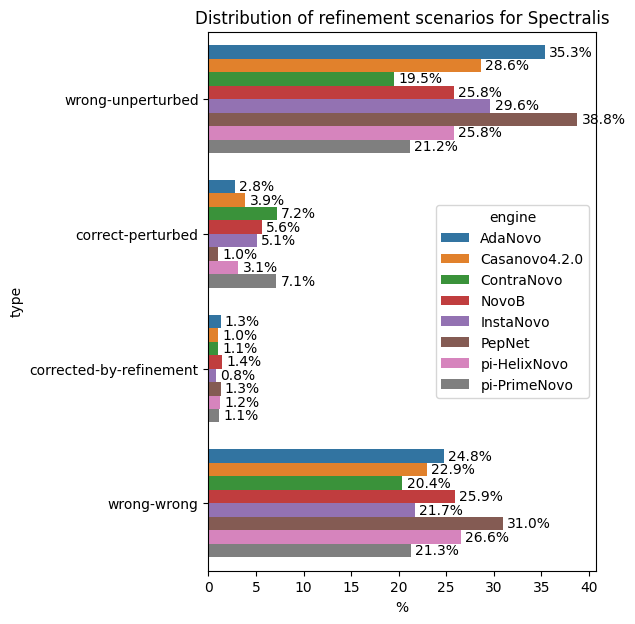

In [66]:
# Your plot
plt.figure(figsize=(5,7))
plt.title('Distribution of refinement scenarios for Spectralis')
ax = sns.barplot(
    data=counts_df[counts_df['refiner']=='Spectralis'],
    hue='engine',
    hue_order=denovo_engines,
    order=['wrong-unperturbed', 'correct-perturbed', 'corrected-by-refinement', 'wrong-wrong'],
    y='type',
    x='%'
)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.show("Suppl_PSMsPerScenario_Spectralis_Detailed")

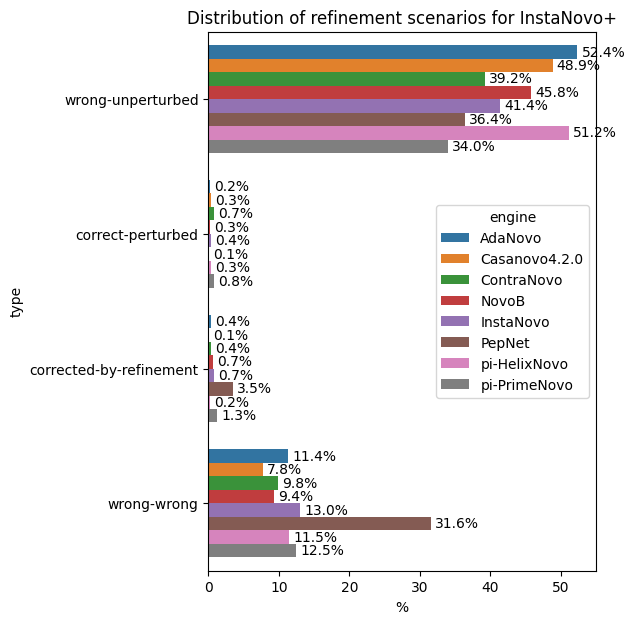

In [67]:
# Your plot
plt.figure(figsize=(5,7))
plt.title('Distribution of refinement scenarios for InstaNovo+')
ax = sns.barplot(
    data=counts_df[counts_df['refiner']=='InstaNovo+'],
    hue='engine',
    hue_order=denovo_engines,
    order=['wrong-unperturbed', 'correct-perturbed', 'corrected-by-refinement', 'wrong-wrong'],
    y='type',
    x='%'
)

# Annotate bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=3)

plt.show("Suppl_PSMsPerScenario_INPlus_Detailed")

In [108]:
# To source data:
import pandas as pd

FIGURE = "Supplementary Figure X"
OUT = "source_data/Source_Data_Suppl_Scenarios.xlsx"
TYPE_ORDER = ['wrong-unperturbed', 'correct-perturbed',
              'corrected-by-refinement', 'wrong-wrong']
PANELS = {"A": "Spectralis", "B": "InstaNovo+"}

sheets = {}
for letter, refiner in PANELS.items():
    d = counts_df[(counts_df['refiner'] == refiner) &
                  (counts_df['type'].isin(TYPE_ORDER))].copy()
    d['type'] = pd.Categorical(d['type'], categories=TYPE_ORDER, ordered=True)
    d = d.sort_values(['type', 'engine']).reset_index(drop=True)
    d = d.rename(columns={'%': 'fraction_of_engine_predictions'})
    d['percent_of_engine_predictions'] = (d['fraction_of_engine_predictions'] * 100).round(3)
    d.insert(0, 'panel', letter); d.insert(0, 'figure', FIGURE)
    sheets[letter] = d[['figure','panel','refiner','engine','type','counts',
                        'fraction_of_engine_predictions','percent_of_engine_predictions']]

with pd.ExcelWriter(OUT, engine='openpyxl') as xl:
    for letter in ['A', 'B']:
        sheets[letter].to_excel(xl, sheet_name=letter, index=False)

In [68]:
counts_df[counts_df['refiner'] == 'InstaNovo+'].groupby('type')['%'].mean()

type
correct-perturbed           0.393881
corrected-by-refinement     0.906672
wrong-unperturbed          43.660560
wrong-wrong                13.358171
Name: %, dtype: float64

In [74]:
levenshtein_df['DL(Gold Standard) - DL(Refined PSM)'] = levenshtein_df['sc_gt_refinement'].apply(
    lambda x: None if x is None else int(x.distances['damerau-levenshtein'])
)
levenshtein_df['DL(Gold Standard) - DL(de novo PSM)'] = levenshtein_df['sc_gt_candidate'].apply(
    lambda x: None if x is None else int(x.distances['damerau-levenshtein'])
)
levenshtein_df['DL(de novo PSM) - DL(Refined PSM)'] = levenshtein_df['sc_candidate_refinement'].apply(
    lambda x: None if x is None else int(x.distances['damerau-levenshtein'])
)

levenshtein_df['L(Gold Standard) - L(Refined PSM)'] = levenshtein_df['sc_gt_refinement'].apply(
    lambda x: None if x is None else int(x.distances['levenshtein'])
)
levenshtein_df['L(Gold Standard) - L(de novo PSM)'] = levenshtein_df['sc_gt_candidate'].apply(
    lambda x: None if x is None else int(x.distances['levenshtein'])
)
levenshtein_df['L(de novo PSM) - L(Refined PSM)'] = levenshtein_df['sc_candidate_refinement'].apply(
    lambda x: None if x is None else int(x.distances['levenshtein'])
)

In [75]:
from denovo_utils.io.save import save_pickle
save_pickle(levenshtein_df, 'levenshtein_table_9_9_26.pkl')

# Plotting levenshtein by refinement type

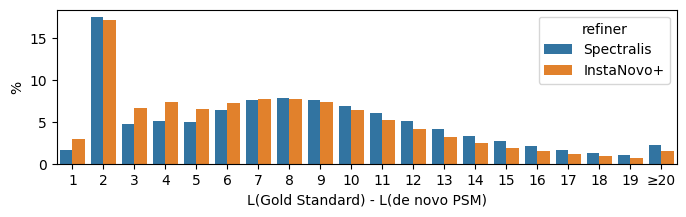

In [76]:
filtered_df = levenshtein_df.loc[
    (levenshtein_df['type'] == 'wrong-unperturbed')
]

l_count_df = filtered_df[['engine', 'L(Gold Standard) - L(de novo PSM)', 'refiner']]
l_count_df['L(Gold Standard) - L(de novo PSM)'] = l_count_df[
    ['L(Gold Standard) - L(de novo PSM)']
].astype(int)

l_count_df = l_count_df.groupby(['refiner', 'engine']).value_counts(normalize=True).reset_index()
l_count_df['%'] = l_count_df['proportion']*100
l_count_df = l_count_df.groupby(['refiner', 'L(Gold Standard) - L(de novo PSM)'])['%'].mean()
l_count_df = l_count_df.reset_index()

summary_plus_20 = l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)']>=20].groupby('refiner').sum().reset_index()
summary_plus_20['L(Gold Standard) - L(de novo PSM)'] = '≥20'

l_count_df = pd.concat([
    l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)']<20],
    summary_plus_20
], ignore_index=True)


plt.figure(figsize=(8,2))
# Create the normalized countplot
sns.barplot(
    data=l_count_df,
    x='L(Gold Standard) - L(de novo PSM)',
    order=[str(x) for x in range(1,20)]+['≥20'],
    y='%',
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+']
)
plt.show("F2Ca_LDScenario1")

In [77]:
source_data_fig2C = []
source_data_fig2D_summary = []
source_data_fig2D_density = []

In [78]:
l_count_df['category'] = 'wrong-unperturbed'
source_data_fig2C.append(l_count_df)

In [79]:
l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)'].isin([1, 2])].groupby('refiner').sum()

,L(Gold Standard) - L(de novo PSM),%,category
refiner,,,
InstaNovo+,3,20.168694,wrong-unperturbedwrong-unperturbed
Spectralis,3,19.164027,wrong-unperturbedwrong-unperturbed


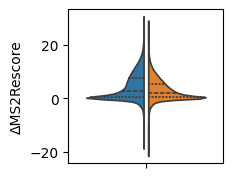

In [80]:
plt.figure(figsize=(2,2))
sns.violinplot(
    filtered_df,
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+'],
    y='ms2rescore_diff_gt_candidate',
    split=True,
    legend=False,
    inner='quart',
    gap=.075
)
plt.ylabel('ΔMS2Rescore')
plt.show("F2Da_scorediff_Scenario1")

In [81]:
import numpy as np, pandas as pd
from scipy.stats import gaussian_kde

def violin_source_data(df, value, group, group_order=None, figure=None,
                       bw_method="scott", cut=2, gridsize=200):
    """Source-data tables for a seaborn violinplot.
    Defaults match sns.violinplot: bw_method='scott', cut=2.
    """
    d = df[[group, value]].dropna()
    order = group_order or list(pd.unique(d[group]))

    srows, drows = [], []
    for g in order:
        v = d.loc[d[group] == g, value].to_numpy()
        kde = gaussian_kde(v, bw_method=bw_method)
        bw = kde.factor * v.std(ddof=1)
        grid = np.linspace(v.min() - cut * bw, v.max() + cut * bw, gridsize)
        srows.append({group: g, "n": v.size, "min": v.min(),
                      "q1": np.percentile(v, 25), "median": np.median(v),
                      "q3": np.percentile(v, 75), "max": v.max(),
                      "mean": v.mean(), "sd": v.std(ddof=1), "bandwidth": bw})
        drows.append(pd.DataFrame({group: g, value: grid, "density": kde(grid)}))

    summary, density = pd.DataFrame(srows), pd.concat(drows, ignore_index=True)
    if figure:
        summary.insert(0, "figure", figure)
        density.insert(0, "figure", figure)
    return summary, density

In [82]:
summary, density = violin_source_data(
    filtered_df,
    value="ms2rescore_diff_gt_candidate",
    group="refiner",
    group_order=['Spectralis', 'InstaNovo+'],   # same as your hue_order
    figure="Figure 2D")

summary = summary.round(4)
density = density.round(5)

summary['category'] = 'wrong-unperturbed'
density['category'] = 'wrong-unperturbed'

In [83]:
source_data_fig2D_summary.append(summary)
source_data_fig2D_density.append(density)

In [84]:
from scipy.stats import ttest_ind

ttest_ind(
    filtered_df[filtered_df['refiner']=='Spectralis']['ms2rescore_diff_gt_candidate'],
    filtered_df[filtered_df['refiner']=='InstaNovo+']['ms2rescore_diff_gt_candidate']
)

TtestResult(statistic=135.43852877642365, pvalue=0.0, df=1048168.0)

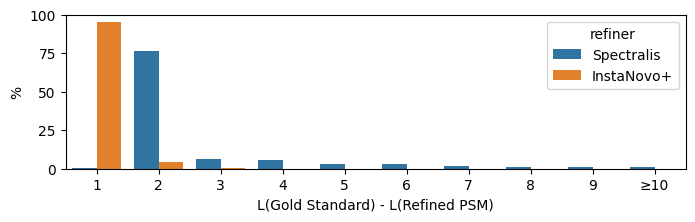

In [85]:
filtered_df = levenshtein_df.loc[
    (levenshtein_df['type'] == 'correct-perturbed')
]

l_count_df = filtered_df[['engine', 'L(Gold Standard) - L(Refined PSM)', 'refiner']]
l_count_df['L(Gold Standard) - L(Refined PSM)'] = l_count_df[
    ['L(Gold Standard) - L(Refined PSM)']
].astype(int)

l_count_df = l_count_df.groupby(['refiner', 'engine']).value_counts(normalize=True).reset_index()
l_count_df['%'] = l_count_df['proportion']*100
l_count_df = l_count_df.groupby(['refiner', 'L(Gold Standard) - L(Refined PSM)'])['%'].mean()
l_count_df = l_count_df.reset_index()

summary_plus_20 = l_count_df[l_count_df['L(Gold Standard) - L(Refined PSM)']>=10].groupby('refiner').sum().reset_index()
summary_plus_20['L(Gold Standard) - L(Refined PSM)'] = '≥10'

l_count_df = pd.concat([
    l_count_df[l_count_df['L(Gold Standard) - L(Refined PSM)']<10],
    summary_plus_20
], ignore_index=True)


plt.figure(figsize=(8,2))
# Create the normalized countplot
sns.barplot(
    data=l_count_df,
    x='L(Gold Standard) - L(Refined PSM)',
    order=[str(x) for x in range(1,10)]+['≥10'],
    y='%',
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+']
)
plt.show("F2Cb_LD_Scenario2")

In [86]:
l_count_df[l_count_df['L(Gold Standard) - L(Refined PSM)'].isin([1, 2])].groupby('refiner').sum()

,L(Gold Standard) - L(Refined PSM),%
refiner,,
InstaNovo+,3,99.727387
Spectralis,3,76.941880


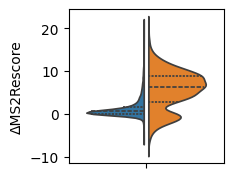

In [87]:
plt.figure(figsize=(2,2))
sns.violinplot(
    filtered_df,
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+'],
    y='ms2rescore_diff_candidate_refinement',
    split=True,
    legend=False,
    inner='quart',
    gap=.075
)
plt.ylabel('ΔMS2Rescore')
plt.show("F2Db_scorediff_Scenario2")

In [88]:
l_count_df['category'] = 'correct-perturbed'
source_data_fig2C.append(l_count_df)

summary, density = violin_source_data(
    filtered_df,
    value="ms2rescore_diff_candidate_refinement",
    group="refiner",
    group_order=['Spectralis', 'InstaNovo+'],   # same as your hue_order
    figure="Figure 2D")

summary = summary.round(4)
density = density.round(5)

summary['category'] = 'correct-perturbed'
density['category'] = 'correct-perturbed'

source_data_fig2D_summary.append(summary)
source_data_fig2D_density.append(density)

---

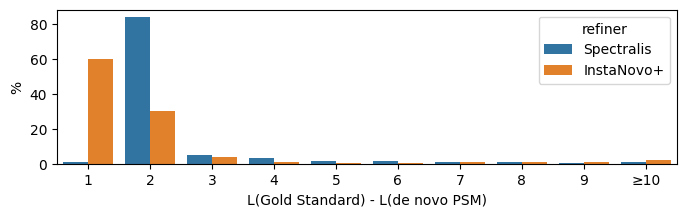

In [89]:
filtered_df = levenshtein_df.loc[
    (levenshtein_df['type'] == 'corrected-by-refinement')
]

l_count_df = filtered_df[['engine', 'L(Gold Standard) - L(de novo PSM)', 'refiner']]
l_count_df['L(Gold Standard) - L(de novo PSM)'] = l_count_df[
    ['L(Gold Standard) - L(de novo PSM)']
].astype(int)

l_count_df = l_count_df.groupby(['refiner', 'engine']).value_counts(normalize=True).reset_index()
l_count_df['%'] = l_count_df['proportion']*100
l_count_df = l_count_df.groupby(['refiner', 'L(Gold Standard) - L(de novo PSM)'])['%'].mean()
l_count_df = l_count_df.reset_index()

summary_plus_20 = l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)']>=10].groupby('refiner').sum().reset_index()
summary_plus_20['L(Gold Standard) - L(de novo PSM)'] = '≥10'

l_count_df = pd.concat([
    l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)']<10],
    summary_plus_20
], ignore_index=True)


plt.figure(figsize=(8,2))
# Create the normalized countplot
sns.barplot(
    data=l_count_df,
    x='L(Gold Standard) - L(de novo PSM)',
    order=[str(x) for x in range(1,10)]+['≥10'],
    y='%',
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+']
)
plt.show("F2Cc_LD_Scenario3")

In [90]:
l_count_df[l_count_df['L(Gold Standard) - L(de novo PSM)'].isin([1, 2, 3])].groupby('refiner').sum()

,L(Gold Standard) - L(de novo PSM),%
refiner,,
InstaNovo+,6,94.213234
Spectralis,6,90.172902


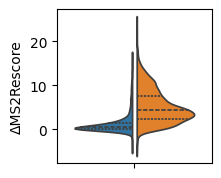

In [91]:
plt.figure(figsize=(2,2))
sns.violinplot(
    filtered_df,
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+'],
    y='ms2rescore_diff_gt_candidate',
    split=True,
    legend=False,
    inner='quart',
    gap=.075
)
plt.ylabel('ΔMS2Rescore')
plt.show("F2Dc_scorediff_Scenario3")

In [92]:
l_count_df['category'] = 'corrected-by-refinement'
source_data_fig2C.append(l_count_df)

summary, density = violin_source_data(
    filtered_df,
    value="ms2rescore_diff_gt_candidate",
    group="refiner",
    group_order=['Spectralis', 'InstaNovo+'],   # same as your hue_order
    figure="Figure 2D")

summary = summary.round(4)
density = density.round(5)

summary['category'] = 'corrected-by-refinement'
density['category'] = 'corrected-by-refinement'

source_data_fig2D_summary.append(summary)
source_data_fig2D_density.append(density)

---

In [33]:
filtered_df.columns

Index(['type', 'engine', 'refiner', 'ms2rescore_diff_gt_candidate',
       'ms2rescore_diff_candidate_refinement', 'ms2rescore_diff_gt_refinement',
       'sc_gt_refinement', 'sc_gt_candidate', 'sc_candidate_refinement',
       'DL(Gold Standard) - DL(Refined PSM)',
       'DL(Gold Standard) - DL(de novo PSM)',
       'DL(de novo PSM) - DL(Refined PSM)',
       'L(Gold Standard) - L(Refined PSM)',
       'L(Gold Standard) - L(de novo PSM)', 'L(de novo PSM) - L(Refined PSM)'],
      dtype='object')

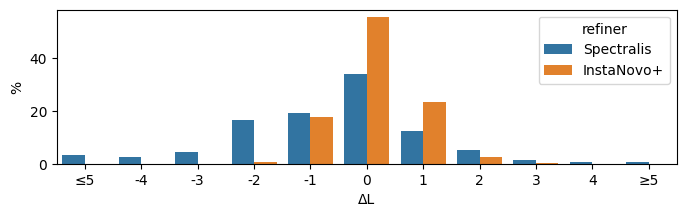

In [93]:
filtered_df = levenshtein_df.loc[
    (levenshtein_df['type'] == 'wrong-wrong')
]

filtered_df['ΔL'] = filtered_df.apply(
    lambda x: x['L(Gold Standard) - L(de novo PSM)'] - x['L(Gold Standard) - L(Refined PSM)'],
    axis=1
)

l_count_df = filtered_df[['engine', 'ΔL', 'refiner']]
l_count_df['ΔL'] = l_count_df[
    ['ΔL']
].astype(int)

l_count_df = l_count_df.groupby(['refiner', 'engine']).value_counts(normalize=True).reset_index()
l_count_df['%'] = l_count_df['proportion']*100
l_count_df = l_count_df.groupby(['refiner', 'ΔL'])['%'].mean()
l_count_df = l_count_df.reset_index()

summary_plus_5 = l_count_df[l_count_df['ΔL']>=5].groupby('refiner').sum().reset_index()
summary_plus_5['ΔL'] = '≥5'

summary_minus_5 = l_count_df[l_count_df['ΔL']<=-5].groupby('refiner').sum().reset_index()
summary_minus_5['ΔL'] = '≤5'

l_count_df = pd.concat([
    l_count_df[(l_count_df['ΔL']<5) & (l_count_df['ΔL']>-5)],
    summary_plus_5,
    summary_minus_5
], ignore_index=True)


plt.figure(figsize=(8,2))
# Create the normalized countplot
sns.barplot(
    data=l_count_df,
    x='ΔL',
    order=['≤5'] + [str(x) for x in range(-4,5)]+['≥5'],
    y='%',
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+']
)
plt.show("F2Cd_LD_Scenario4")

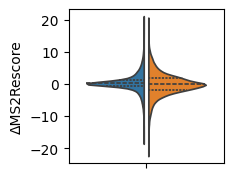

In [94]:
plt.figure(figsize=(2,2))
sns.violinplot(
    filtered_df,
    hue='refiner',
    hue_order=['Spectralis', 'InstaNovo+'],
    y='ms2rescore_diff_candidate_refinement',
    split=True,
    legend=False,
    inner='quart',
    gap=.075
)
plt.ylabel('ΔMS2Rescore')
plt.show("F2Dd_scorediff_Scenario4")

In [95]:
l_count_df['category'] = 'wrong-wrong'
source_data_fig2C.append(l_count_df)

summary, density = violin_source_data(
    filtered_df,
    value="ms2rescore_diff_candidate_refinement",
    group="refiner",
    group_order=['Spectralis', 'InstaNovo+'],   # same as your hue_order
    figure="Figure 2D")

summary = summary.round(4)
density = density.round(5)

summary['category'] = 'wrong-wrong'
density['category'] = 'wrong-wrong'

source_data_fig2D_summary.append(summary)
source_data_fig2D_density.append(density)

---

In [96]:
levenshtein_df.columns

Index(['type', 'engine', 'refiner', 'ms2rescore_diff_gt_candidate',
       'ms2rescore_diff_candidate_refinement', 'ms2rescore_diff_gt_refinement',
       'sc_gt_refinement', 'sc_gt_candidate', 'sc_candidate_refinement',
       'DL(Gold Standard) - DL(Refined PSM)',
       'DL(Gold Standard) - DL(de novo PSM)',
       'DL(de novo PSM) - DL(Refined PSM)',
       'L(Gold Standard) - L(Refined PSM)',
       'L(Gold Standard) - L(de novo PSM)', 'L(de novo PSM) - L(Refined PSM)'],
      dtype='object')

In [97]:
source_data_fig2 = levenshtein_df.copy()

In [98]:
_ = source_data_fig2.pop('sc_gt_refinement')
_ = source_data_fig2.pop('sc_gt_candidate')
_ = source_data_fig2.pop('sc_candidate_refinement')

In [101]:
source_data_fig2.to_parquet('source_data/Source_Data_Figure2.parquet')

In [102]:
sd_fig2c = pd.concat(source_data_fig2C, ignore_index=True)
sd_fig2d_summary = pd.concat(source_data_fig2D_summary, ignore_index=True)
sd_fig2d_density = pd.concat(source_data_fig2D_density, ignore_index=True)

In [107]:
with pd.ExcelWriter('source_data/Source_Data_Figure2.xlsx', engine='openpyxl',
                    mode='a', if_sheet_exists='replace') as xl:
    sd_fig2c.to_excel(xl, sheet_name='C', index=False)
    sd_fig2d_summary.to_excel(xl, sheet_name='D_summary', index=False)
    sd_fig2d_density.to_excel(xl, sheet_name='D_density', index=False)